In [1]:
%load_ext autoreload
%autoreload 2

# DC4 Positron Goal 2: Galactic 511 keV Disk Scale Height
**Objective**

This notebook addresses the second DC4 positron goal using the 509--513 keV line data:

2. Determine the scale height of the Galactic 511 keV disk and prepare its comparison with the $^{26}$ Al distribution.

## Setup

In [2]:
# Setting the root path for the imports
from pathlib import Path
import sys

working_dir = Path.cwd()
repo_root = (
    working_dir.parent 
    if working_dir.name == "notebooks"
    else working_dir
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

### Imports

In [3]:
import cosipy as cp

In [4]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
import healpy as hp
import astropy.units as u

from histpy import Histogram

### Paths to imput products

In [6]:
from src import path_to_files as paths


## Load the 511 keV image reconstruction

In [7]:
reconstructed_511 = Histogram.open(
    paths.reconstructed_511_image_path, 
    name="reconstructed_511")

In [8]:
print(f"Reconstructed 511 keV image shape: {reconstructed_511.shape}")
print(f"Reconstructed 511 keV image axes: {reconstructed_511.axes.labels}")
print(f"Reconstructed 511 keV image unit: {reconstructed_511.unit}")

Reconstructed 511 keV image shape: (3072, 1)
Reconstructed 511 keV image axes: ['lb' 'Ei']
Reconstructed 511 keV image unit: 1 / (s sr cm2)


## Extract HEALPix coordinates and 511 keV intensity

In [9]:
sky_axis = reconstructed_511.axes["lb"]

# HEALPix stores sky directions as integer pixel indices
# sky_axis.npix -> total number of pixels in the sky axis
# Create an array of pixel indices from 0 to sky_axis.npix - 1
pixel_index = np.arange(sky_axis.npix)

In [10]:

# Convert every HEALPix pixel index into an astronomical coordinate (l, b) in degrees
# The result object contains the galactic longitude (l) and latitude (b) for each pixel index
pixel_coordinates = sky_axis.pix2skycoord(pixel_index)

In [11]:
# Galactic longitude (l) describes position along the galactic plane, 
# measured in degrees from the center of the galaxy
# wrapping at 180 degrees changes the conventional (0,360) range to (-180, 180) degrees
galactic_longitude = pixel_coordinates.galactic.l.wrap_at(180 * u.deg)

In [12]:
# Galactic latitude (b) describes position above or below the galactic plane,
# The plane itself is located at b = 0 degrees
galactic_latitude = pixel_coordinates.galactic.b

In [13]:
# Select the reconstructed intensity in the only energy bin (511 keV)
# The result contains one intensioty value for each pixel in the sky axis

intensity_511 = reconstructed_511[:, 0]

In [14]:
# Verify that the coordinates and intensity describe the same 
# full sky map before constructing the latitude profile

print('number of pixels:', sky_axis.npix)
print(
    'Longitude range:',
    galactic_longitude.min(), 'to', galactic_longitude.max()
)
print(
    'Latitude range:',
    galactic_latitude.min(), 'to', galactic_latitude.max()
)
print('Intensity shape:', intensity_511.shape)
print('Intensity unit:', reconstructed_511.unit)

number of pixels: 3072
Longitude range: -180d00m00s to 177d11m15s
Latitude range: -87d04m32.95071462s to 87d04m32.95071462s
Intensity shape: (3072,)
Intensity unit: 1 / (s sr cm2)


## Construct the preliminary Galactic latitude profile

In [15]:
# Convert the galactic latitudes into plain nurical values in degrees
# This makes them easier to use with numpy and binning.

latitute_values = galactic_latitude.to_value(u.deg)

In [16]:
# Extract the numerical intensity values while preserving the physical unit separetely
# in reconstructed_511.unit

intensity_values = intensity_511.to_value(reconstructed_511.unit)

In [17]:
# Define latitude-bin boundaries from -90 to _90 degrees
# Each bin is 5 degrees wide

latitude_edges = np.arange(-90, 95, 5)

# Calculate the center of each latitude bin for plotting
#  (This is something that is done everytime we plot a histogram)
latitude_centers = 0.5 * (latitude_edges[:-1] + latitude_edges[1:])

In [18]:
# Create empty array to hold the mean intensity and the number of pixels in each latitude bin

mean_intensity = np.full(
    latitude_centers.shape, np.nan, dtype=float)

pixels_per_bin = np.zeros(latitude_centers.shape, dtype=int)

In [19]:
for index, (lower_edge, upper_edge) in enumerate(
    zip(latitude_edges[:-1], latitude_edges[1:])
    ):

    # select pixels whose galactic latitude falls inside this interval

    latitude_mask = (
        (latitute_values >= lower_edge)
        & (latitute_values < upper_edge)
        )
    # Count how many HEALPix pixels were selected
    pixels_per_bin[index] = np.count_nonzero(latitude_mask)

    # replace nan with the mean intensity of the selected pixels
    if pixels_per_bin[index] > 0:
        mean_intensity[index] = np.mean(intensity_values[latitude_mask])

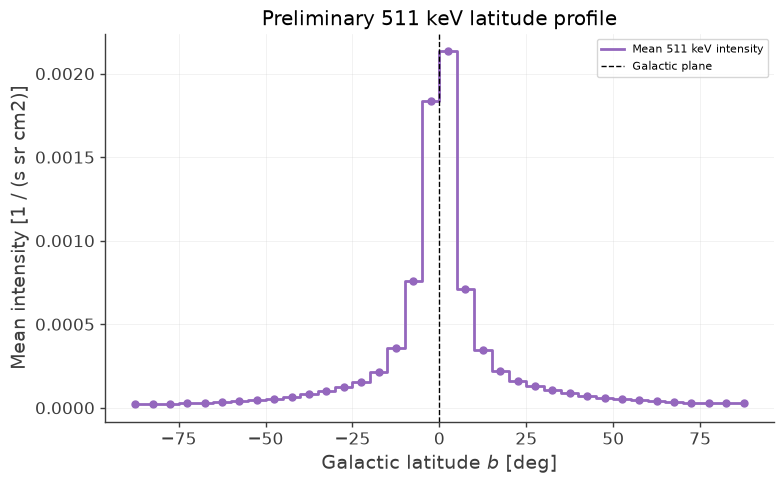

In [20]:
# **Visualize the latitude profile of the 511 keV reconstructed image**
fig, ax = plt.subplots(figsize=(8, 5))

# Draw the mean intensity calculated in each latitude bin.
ax.step(
    latitude_centers,
    mean_intensity,
    where="mid",
    color="tab:purple",
    label="Mean 511 keV intensity",
)

# Mark the center of every latitude bin.
ax.scatter(
    latitude_centers,
    mean_intensity,
    color="tab:purple",
    s=25,
)

# Mark the Galactic plane at b = 0 degrees.
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Galactic plane",
)

ax.set_xlabel(r"Galactic latitude $b$ [deg]")
ax.set_ylabel(
    f"Mean intensity [{reconstructed_511.unit}]"
)
ax.set_title("Preliminary 511 keV latitude profile")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [21]:
# Convert Galactic longitude from an Astropy Quantity to a NumPy array
# containing numerical values in degrees.
longitude_values = galactic_longitude.to_value(u.deg)

# Calculate each pixel's angular distance in longitude from l = 0 deg.
# The absolute value combines the positive and negative sides of the Galaxy.
absolute_longitude = np.abs(longitude_values)

# Select all pixels located within 20 degrees of the Galactic center.
# No latitude cut is applied here.
central_region_mask = absolute_longitude < 20

# Select pixels between 20 and 90 degrees from the Galactic center.
# This includes both positive and negative Galactic longitudes.
disk_region_mask = (
    (absolute_longitude >= 20)
    & (absolute_longitude <= 90)
)

# Count the number of HEALPix pixels selected by each mask.
print(
    "Central-region pixels:",
    np.count_nonzero(central_region_mask),
)

print(
    "Disk-region pixels:",
    np.count_nonzero(disk_region_mask),
)

Central-region pixels: 352
Disk-region pixels: 1200


In [22]:
# Create arrays for the disk-region latitude profile

disk_mean_intensity = np.full(
    latitude_centers.shape, np.nan, dtype=float)    

disk_pixels_per_bin = np.zeros(latitude_centers.shape, dtype=int)

In [23]:
# Process one galactic latitude interval at a time
for index, (lower_edge, upper_edge) in enumerate(
    zip(latitude_edges[:-1], latitude_edges[1:])
    ):

   # select pixels inside the current latitude interval
   latitude_bin_mask = (
       (latitute_values >= lower_edge)
       & (latitute_values < upper_edge)
   )

   # keep only pixels that are both inside the latitude bin and the disk region
   selected_pixels = latitude_bin_mask & disk_region_mask

   # Count how many HEALPix pixels were selected
   disk_pixels_per_bin[index] = np.count_nonzero(selected_pixels)

   # calculatre the mean intensity of the selected pixels, if any were selected
   if disk_pixels_per_bin[index] > 0:
       disk_mean_intensity[index] = np.mean(
           intensity_values[selected_pixels]
       )
       

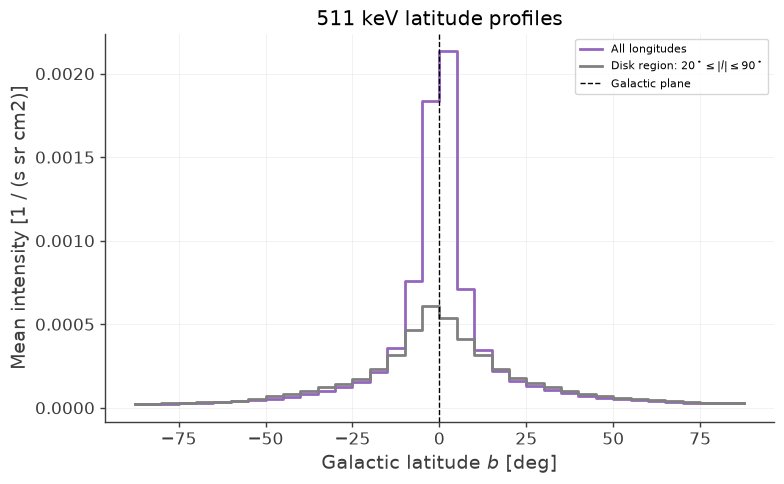

In [24]:
# Compare the full-sky latitude profile with the profile obtained
# after excluding the central Galactic longitude region.
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the profile calculated using all Galactic longitudes.
ax.step(
    latitude_centers,
    mean_intensity,
    where="mid",
    color="tab:purple",
    linewidth=2,
    label="All longitudes",
)

# Plot the profile calculated only in the selected disk region.
ax.step(
    latitude_centers,
    disk_mean_intensity,
    where="mid",
    color="gray",
    linewidth=2,
    label=r"Disk region: $20^\circ \leq |l| \leq 90^\circ$",
)

# Mark the Galactic plane at b = 0 degrees.
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Galactic plane",
)

ax.set_xlabel(r"Galactic latitude $b$ [deg]")
ax.set_ylabel(
    f"Mean intensity [{reconstructed_511.unit}]"
)
ax.set_title("511 keV latitude profiles")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Prepare the disk latitude profile for fitting

In [25]:
# Store the intensity spread in each latitude bin.
disk_intensity_std = np.full(
    latitude_centers.shape,
    np.nan,
)

# Store the nominal uncertainty of each bin mean.
disk_mean_error = np.full(
    latitude_centers.shape,
    np.nan,
)

In [ ]:
# calculate the intensity spread inside each disk latitude bin
for index, (lower_edge, upper_edge) in enumerate(
    zip(latitude_edges[:-1], latitude_edges[1:])
    ):


       latitude_bin_mask = (
           (latitute_values >= lower_edge)
           & (latitute_values < upper_edge)
         )

       selected_pixels = latitude_bin_mask & disk_region_mask

      # Calculate the standard deviation of the intensity values in the selected pixels
       if np.count_nonzero(selected_pixels) > 1:
              disk_intensity_std[index] = np.std(
                intensity_values[selected_pixels],
                ddof=1
              )

              disk_mean_error[index] = (
                  disk_intensity_std[index]
                  / np.sqrt(disk_pixels_per_bin[index])
              )
        

In [28]:
# Select bins with a valid mean intensity and a positive uncertainty.
valid_profile_bins = (
    np.isfinite(disk_mean_intensity)
    & np.isfinite(disk_mean_error)
    & (disk_mean_error > 0)
)

print("Total latitude bins:", latitude_centers.size)
print(
    "Valid profile bins:",
    np.count_nonzero(valid_profile_bins),
)

Total latitude bins: 36
Valid profile bins: 36


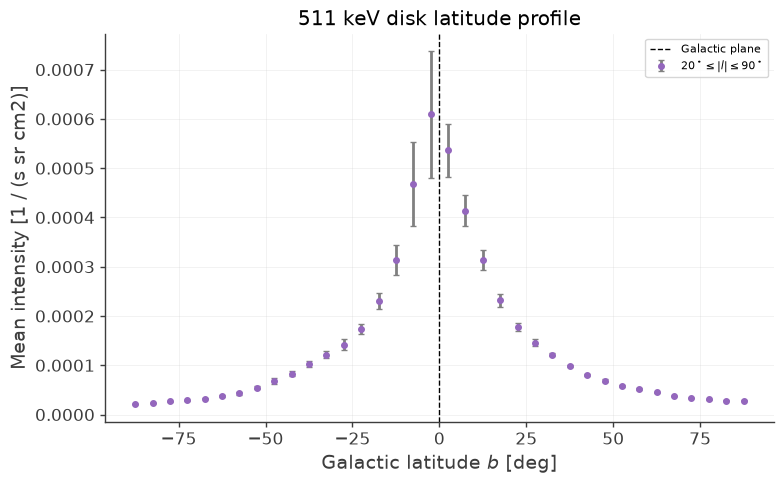

In [29]:
# Plot the disk latitude profile with nominal error bars.
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    latitude_centers[valid_profile_bins],
    disk_mean_intensity[valid_profile_bins],
    yerr=disk_mean_error[valid_profile_bins],
    fmt="o",
    markersize=4,
    color="tab:purple",
    ecolor="gray",
    capsize=2,
    label=r"$20^\circ \leq |l| \leq 90^\circ$",
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Galactic plane",
)

ax.set_xlabel(r"Galactic latitude $b$ [deg]")
ax.set_ylabel(
    f"Mean intensity [{reconstructed_511.unit}]"
)
ax.set_title("511 keV disk latitude profile")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()